In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir("/content/drive/My Drive/klines csv/prices_cleaned"))

['ETHUSDT', 'AVAXUSDT', 'BNBUSDT', 'XRPUSDT', 'BCHUSDT', 'SOLUSDT', 'LINKUSDT', 'HBARUSDT', 'TRXUSDT', 'BTCUSDT', 'ADAUSDT', 'XLMUSDT', 'ZECUSDT', 'SHIBUSDT', 'AAVEUSDT', 'ARBUSDT', 'SUIUSDT', 'WLFIUSDT', 'LTCUSDT', 'ASTERUSDT', 'TONUSDT', 'DOTUSDT', 'PENGUUSDT', 'FILUSDT', 'FIOUSDT', 'NEARUSDT', 'BARDUSDT', 'PEPEUSDT', 'PUMPUSDT', 'VIRTUALUSDT', 'XPLUSDT', 'ZROUSDT', 'TRUMPUSDT', 'UNIUSDT', 'ZKCUSDT', 'TAOUSDT', 'QNTUSDT', 'FFUSDT']


In [ ]:
import os
print(os.listdir("/content/drive/My Drive/klines csv/monthly klines csv/prices_cleaned"))

['SOLUSDT', 'ETHUSDT', 'BTCUSDT', 'TRXUSDT', 'XRPUSDT', 'ADAUSDT', 'BNBUSDT', 'BCHUSDT']


In [ ]:
#XGBoost base


Training: SOLUSDT
SOLUSDT RMSE: 31.493883
SOLUSDT Mean Actual Price: 152.974615
SOLUSDT NRMSE (% of mean price): 0.2059%


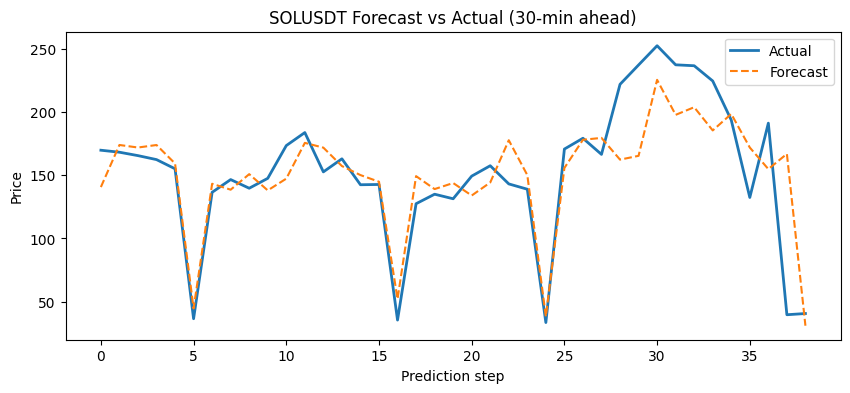


Training: ETHUSDT
ETHUSDT RMSE: 573.915737
ETHUSDT Mean Actual Price: 2851.582564
ETHUSDT NRMSE (% of mean price): 0.2013%


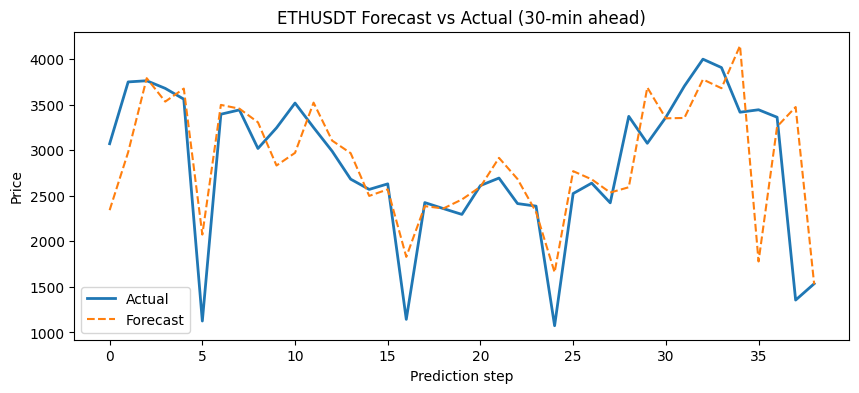


Training: BTCUSDT
BTCUSDT RMSE: 16016.191919
BTCUSDT Mean Actual Price: 64286.045128
BTCUSDT NRMSE (% of mean price): 0.2491%


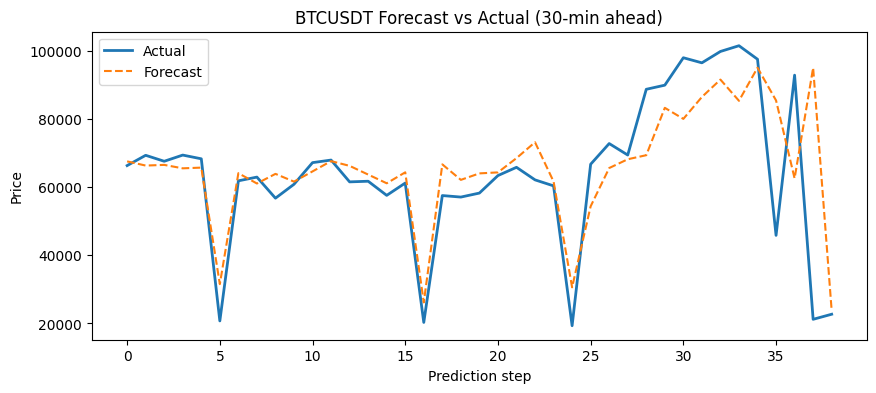


Training: TRXUSDT
TRXUSDT RMSE: 0.056514
TRXUSDT Mean Actual Price: 0.147867
TRXUSDT NRMSE (% of mean price): 0.3822%


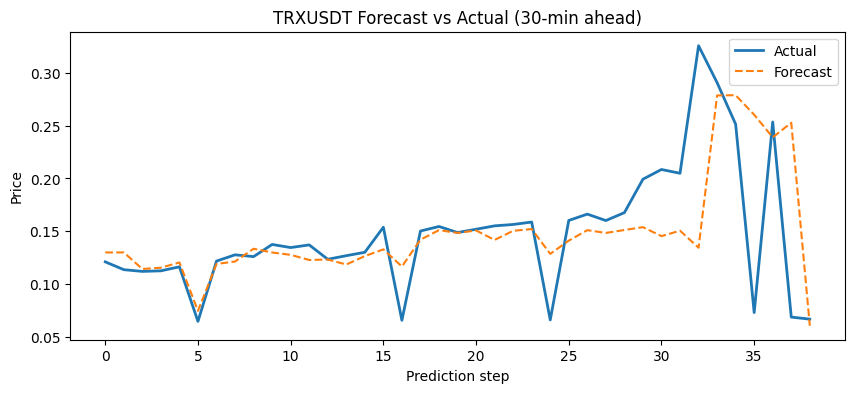


Training: XRPUSDT
XRPUSDT RMSE: 0.484814
XRPUSDT Mean Actual Price: 0.774849
XRPUSDT NRMSE (% of mean price): 0.6257%


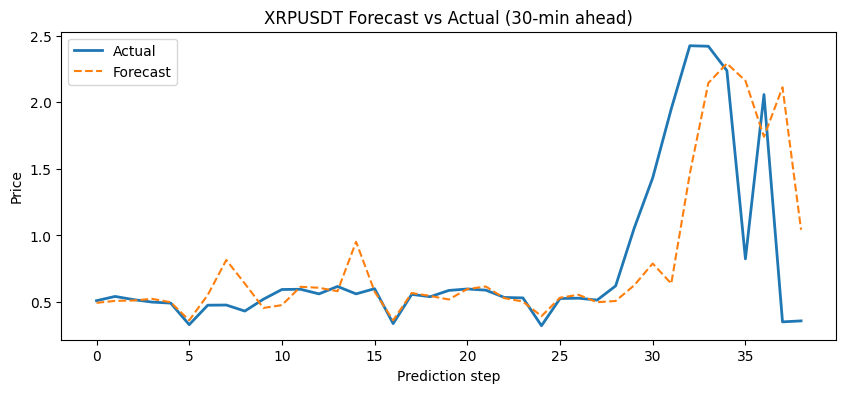


Training: ADAUSDT
ADAUSDT RMSE: 0.158134
ADAUSDT Mean Actual Price: 0.528646
ADAUSDT NRMSE (% of mean price): 0.2991%


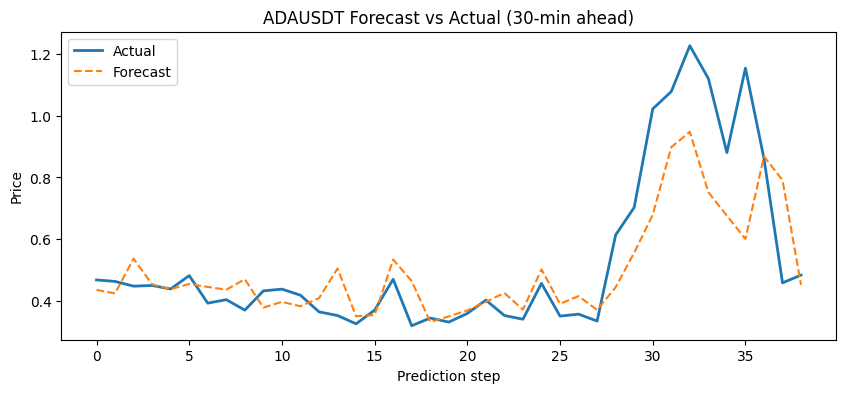


Training: BNBUSDT
BNBUSDT RMSE: 95.822187
BNBUSDT Mean Actual Price: 545.711282
BNBUSDT NRMSE (% of mean price): 0.1756%


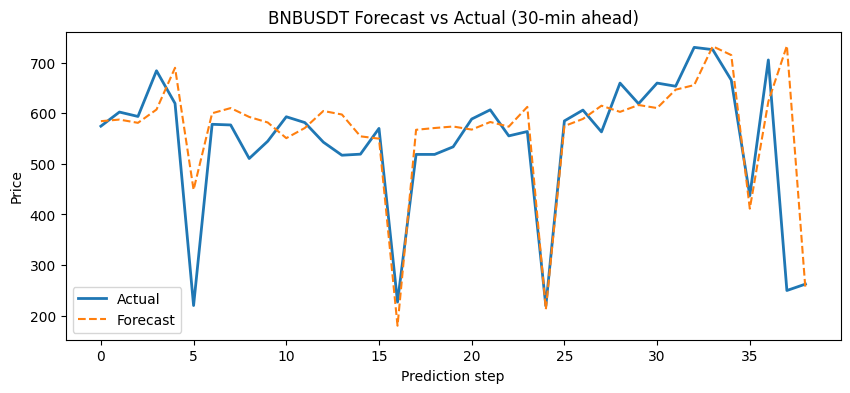


Training: BCHUSDT
BCHUSDT RMSE: 89.394429
BCHUSDT Mean Actual Price: 367.982051
BCHUSDT NRMSE (% of mean price): 0.2429%


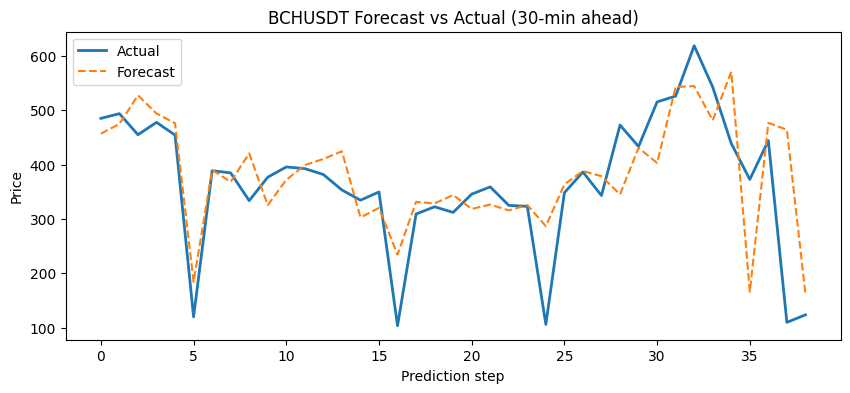

,coin,actual,forecast
0,SOLUSDT,169.93,140.741852
1,SOLUSDT,168.35,174.084412
2,SOLUSDT,165.65,172.070923
3,SOLUSDT,162.50,174.056519
4,SOLUSDT,155.22,159.417877
...,...,...,...
307,BCHUSDT,438.70,570.695435
308,BCHUSDT,372.50,165.844193
309,BCHUSDT,444.00,476.576324
310,BCHUSDT,109.50,463.969971



RMSE Summary


,RMSE,Mean_Actual_Price,NRMSE_Mean,NRMSE_Percent
BNBUSDT,95.822187,545.711282,0.175591,0.175591
ETHUSDT,573.915737,2851.582564,0.201262,0.201262
SOLUSDT,31.493883,152.974615,0.205877,0.205877
BCHUSDT,89.394429,367.982051,0.242931,0.242931
BTCUSDT,16016.191919,64286.045128,0.249139,0.249139
ADAUSDT,0.158134,0.528646,0.299131,0.299131
TRXUSDT,0.056514,0.147867,0.382192,0.382192
XRPUSDT,0.484814,0.774849,0.625689,0.625689


In [ ]:

import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

#lags to be 2xhorizon, so 2x30 because 30 minutes
data_folder = "/content/drive/My Drive/klines csv/monthly klines csv/prices_cleaned"
HORIZON = 7
N_LAGS = 14

results = {}
all_tables = []

#table of lags
def create_lags(df, n_lags):
    for i in range(1, n_lags + 1):
        df[f"lag_{i}"] = df["close"].shift(i)
    return df

#total files
files = os.listdir(data_folder)

#looping through coins
for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv","")
    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)
    df.columns = ["index","close","time"]

    # ensure numeric just in case
    df["close"] = pd.to_numeric(df["close"], errors="coerce")

    # ensuring chronological order, just in case
    df = df.sort_values("time")

    df = df[["close"]]


    # Handle tiny-price coins

    tiny_price = df["close"].median() < 0.01

    if tiny_price:
        print("Tiny price detected → using log price")
        df["close"] = np.log(df["close"])

    df["target"] = df["close"].shift(-HORIZON)

    df = create_lags(df, N_LAGS)

    df = df.dropna().reset_index(drop=True)

    #train test split
    X = df.drop(columns=["target"])
    y = df["target"]

    split = int(len(df) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    # Model
    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)

    #predict
    preds = []
    actual = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]

        if tiny_price:
            preds.append(np.exp(pred))
            actual.append(np.exp(y_test.iloc[i]))
        else:
            preds.append(pred)
            actual.append(y_test.iloc[i])

    preds = np.array(preds)
    actual = np.array(actual)

    # raw RMSE
    rmse = np.sqrt(mean_squared_error(actual, preds))

    # NEW: normalize by mean actual price
    mean_actual_price = actual.mean()
    nrmse_mean = rmse / mean_actual_price
    nrmse_pct = nrmse_mean

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Mean": nrmse_mean,
        "NRMSE_Percent": nrmse_pct
    }

    print(f"{coin} RMSE: {rmse:.6f}")
    print(f"{coin} Mean Actual Price: {mean_actual_price:.6f}")
    print(f"{coin} NRMSE (% of mean price): {nrmse_pct:.4f}%")

    # Ssave table
    table = pd.DataFrame({
        "coin": coin,
        "actual": actual,
        "forecast": preds
    })

    all_tables.append(table)

    # Plot
    plt.figure(figsize=(10,4))
    plt.plot(actual, label="Actual", linewidth=2)
    plt.plot(preds, label="Forecast", linestyle="--")
    plt.title(f"{coin} Forecast vs Actual (30-min ahead)")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

#final table
final_table = pd.concat(all_tables, ignore_index=True)

display(final_table)

# save predictions
final_table.to_csv("NEW!_xgboost_forecasts.csv", index=False)

#rmse summary
rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("NRMSE_Percent")

rmse_table.to_csv("NEW!_RMSE1_normalized.csv", index=True)

print("\nRMSE Summary")
display(rmse_table)

In [ ]:
from google.colab import files
files.download('NEW!_xgboost_forecasts.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 4.5 MB/s eta 0:00:00


Files detected: 8
['SOLUSDT', 'ETHUSDT', 'BTCUSDT', 'TRXUSDT', 'XRPUSDT', 'ADAUSDT', 'BNBUSDT', 'BCHUSDT']

Training: SOLUSDT
SOLUSDT RMSE: 101.74904604586703


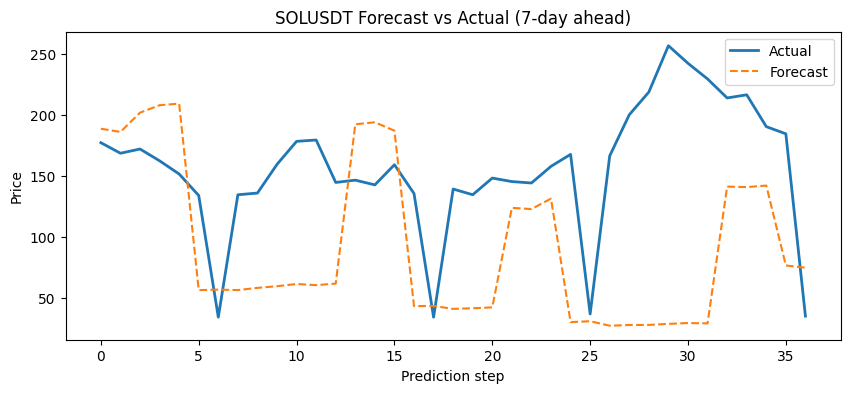


Training: ETHUSDT
ETHUSDT RMSE: 1394.2847483298603


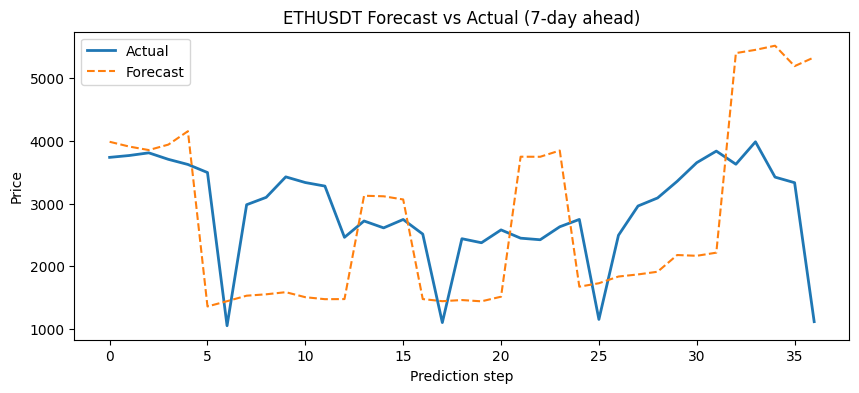


Training: BTCUSDT
BTCUSDT RMSE: 37940.47388512333


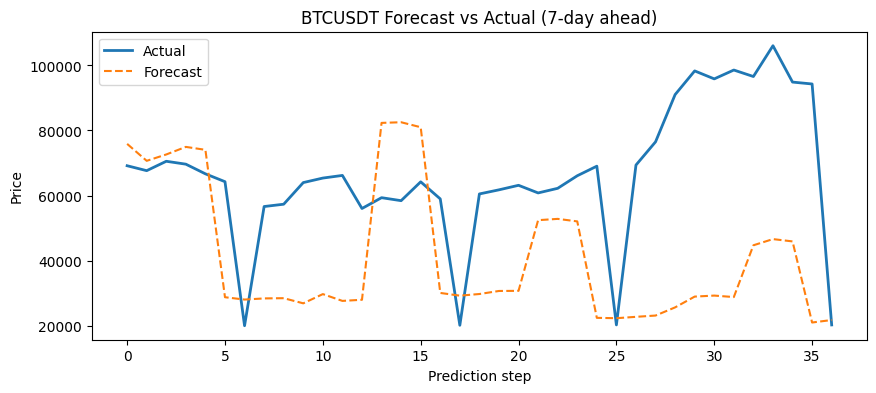


Training: TRXUSDT
TRXUSDT RMSE: 0.10737303908117152


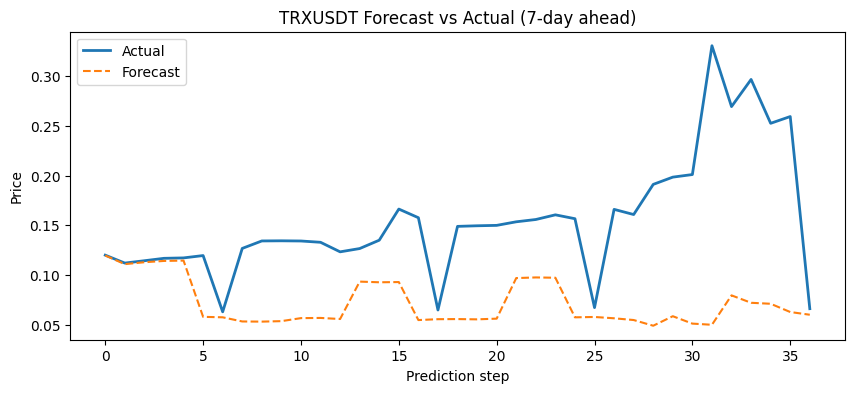


Training: XRPUSDT
XRPUSDT RMSE: 0.7146400594654275


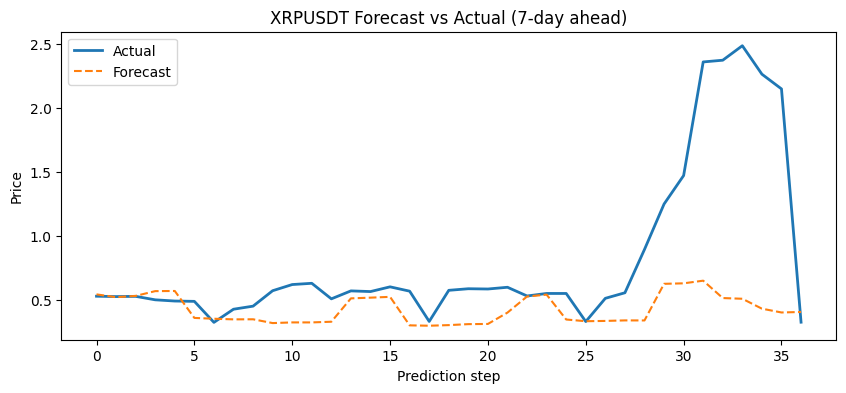


Training: ADAUSDT
ADAUSDT RMSE: 0.21101787339768022


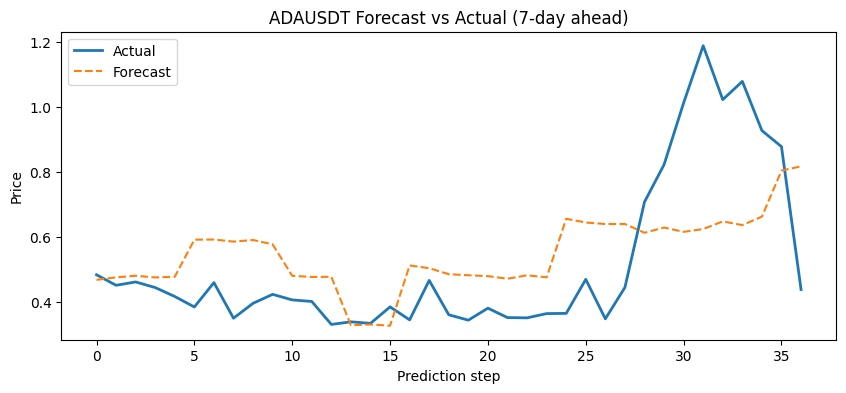


Training: BNBUSDT
BNBUSDT RMSE: 252.09234725002523


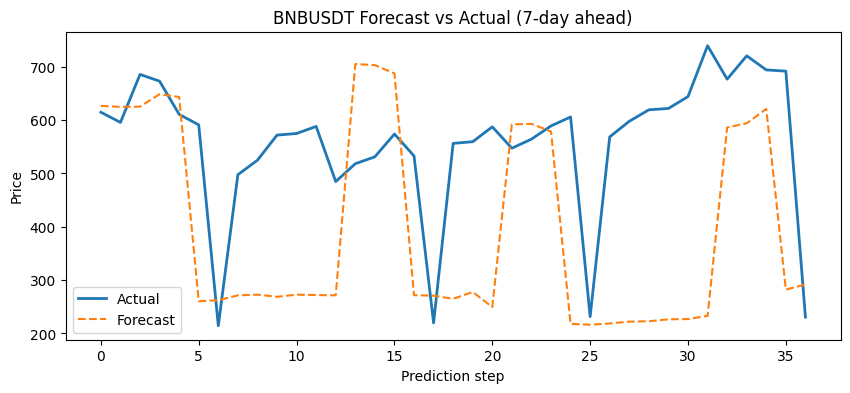


Training: BCHUSDT
BCHUSDT RMSE: 217.16197875466975


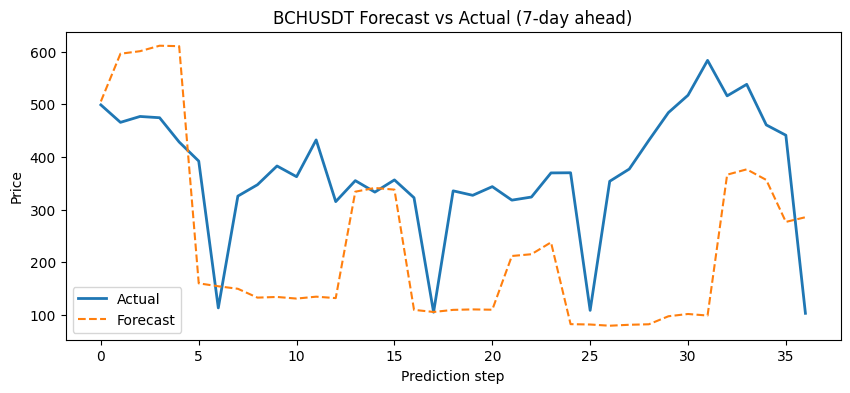

,coin,actual_price,forecast_price
0,SOLUSDT,176.95,188.384955
1,SOLUSDT,168.32,185.787854
2,SOLUSDT,171.78,201.542732
3,SOLUSDT,162.12,207.649769
4,SOLUSDT,151.30,208.937981
...,...,...,...
32,BCHUSDT,516.20,366.252405
33,BCHUSDT,538.10,376.389020
34,BCHUSDT,460.90,356.256292
35,BCHUSDT,441.30,276.407729



RMSE Summary


,RMSE,Mean_Actual_Price,NRMSE_Percent
TRXUSDT,0.107373,0.155034,0.692580
ADAUSDT,0.211018,0.516959,0.408190
XRPUSDT,0.714640,0.813641,0.878324
SOLUSDT,101.749046,155.928108,0.652538
BCHUSDT,217.161979,372.651351,0.582748
BNBUSDT,252.092347,558.116486,0.451684
ETHUSDT,1394.284748,2895.692973,0.481503
BTCUSDT,37940.473885,66489.435946,0.570624


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import optuna

data_folder = "/content/drive/My Drive/klines csv/monthly klines csv/prices_cleaned"

HORIZON = 7
N_LAGS = 14

results = {}
all_tables = []

# Lag funct
def create_lags(df, col, n_lags):

    for i in range(1, n_lags + 1):
        df[f"{col}_lag_{i}"] = df[col].shift(i)

    return df

files = os.listdir(data_folder)

print("Files detected:", len(files))
print(files[:10])

for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv","")

    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)

    df.columns = ["index","close","time"]

    df["close"] = pd.to_numeric(df["close"], errors="coerce")

    df = df.sort_values("time")
    # Returns
    df["return"] = np.log(df["close"] / df["close"].shift(1))


    # rolling vol
    df["vol_30"] = df["return"].rolling(30).std()
    df["vol_60"] = df["return"].rolling(60).std()

    df["target"] = df["return"].shift(-HORIZON)

    df = create_lags(df, "return", N_LAGS)
    df = create_lags(df, "vol_30", 10)
    df = create_lags(df, "vol_60", 10)

    df = df.dropna().reset_index(drop=True)

    X = df.drop(columns=["target","close","time"])
    y = df["target"]

    split = int(len(df) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]
    # Model
    model = xgb.XGBRegressor(

        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42

    )

    model.fit(X_train, y_train)

    preds_return = []
    actual_return = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]

        preds_return.append(pred)

        actual_return.append(y_test.iloc[i])


    actual_price = df["close"].iloc[split::7].values[:len(preds_return)]

    start_price = df["close"].iloc[split]

    preds_price = []

    price = start_price

    for r in preds_return:

        price = price * np.exp(r)

        preds_price.append(price)


    rmse = np.sqrt(mean_squared_error(actual_price, preds_price))
    mean_actual_price = np.mean(actual_price)
    nrmse_percent = (rmse / mean_actual_price)

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Percent": nrmse_percent
    }

    print(f"{coin} RMSE:", rmse)



    table = pd.DataFrame({

        "coin": coin,
        "actual_price": actual_price,
        "forecast_price": preds_price

    })

    all_tables.append(table)



    plt.figure(figsize=(10,4))

    plt.plot(actual_price, label="Actual", linewidth=2)
    plt.plot(preds_price, label="Forecast", linestyle="--")

    plt.title(f"{coin} Forecast vs Actual (7-day ahead)")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")

    plt.legend()

    plt.show()



final_table = pd.concat(all_tables)

display(final_table)

final_table.to_csv("NEW!_xgb_feature_forecasts.csv", index=False)


rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("RMSE")

print("\nRMSE Summary")
display(rmse_table)
rmse_table.to_csv("NEW!_xgb_feature_rmses.csv", index=True)

In [ ]:
from google.colab import files
files.download('NEW!_xgb_feature_forecasts.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_4987/4090235654.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-10 09:41:34,439] A new study created in memory with name: no-name-1428946e-ff40-461f-b0ed-6614b4295adf



Training: SOLUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-10 09:41:34,767] Trial 0 finished with value: 49.2626440305715 and parameters: {'n_estimators': 139, 'max_depth': 10, 'learning_rate': 0.014385619352012779, 'subsample': 0.6420818753640125, 'colsample_bytree': 0.5009557713731279, 'gamma': 2.3101535808535174, 'reg_alpha': 3.407385137241641, 'reg_lambda': 1.6708839697351046}. Best is trial 0 with value: 49.2626440305715.
[I 2026-04-10 09:41:34,917] Trial 1 finished with value: 34.177011908978194 and parameters: {'n_estimators': 119, 'max_depth': 6, 'learning_rate': 0.10963640278636852, 'subsample': 0.7752394053837907, 'colsample_bytree': 0.5348823323644144, 'gamma': 4.840823465834468, 'reg_alpha': 3.085675016987553, 'reg_lambda': 0.07906286000296525}. Best is trial 1 with value: 34.177011908978194.
[I 2026-04-10 09:41:35,237] Trial 2 finished with value: 36.37253309339633 and parameters: {'n_estimators': 482, 'max_depth': 3, 'learning_rate': 0.1470912387480334, 'subsample': 0.6011812153634217, 'colsample_bytree': 0.69977732876

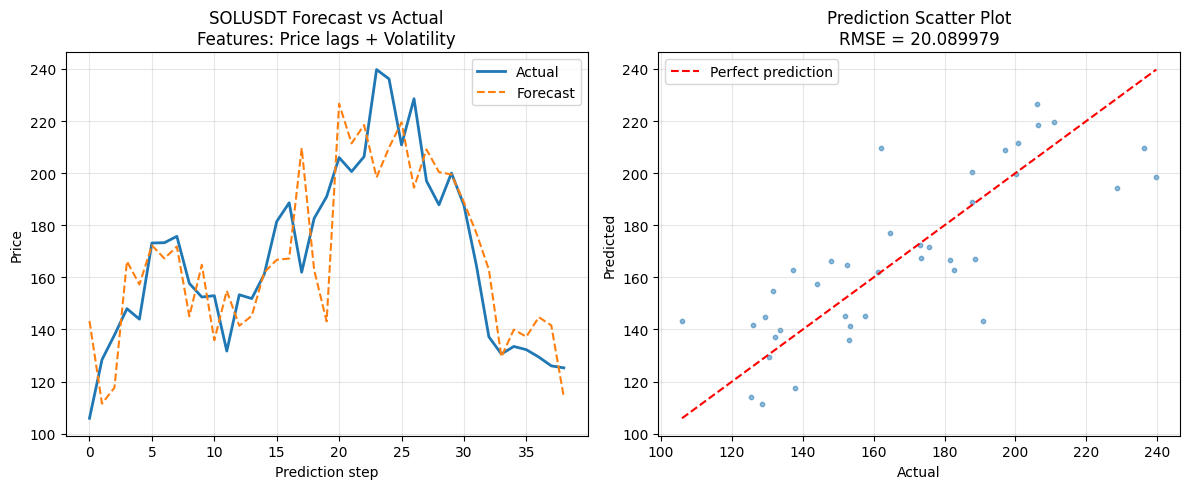

/tmp/ipykernel_4987/4090235654.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-10 09:41:48,359] A new study created in memory with name: no-name-f084dce1-e1a1-44e1-97a4-16db9f9c09f6



Training: ETHUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-10 09:41:49,792] Trial 0 finished with value: 304.37235124432004 and parameters: {'n_estimators': 394, 'max_depth': 10, 'learning_rate': 0.14383506716383787, 'subsample': 0.7041563267853852, 'colsample_bytree': 0.9038527599643371, 'gamma': 4.039569073742568, 'reg_alpha': 2.874834590198577, 'reg_lambda': 3.449017212522834}. Best is trial 0 with value: 304.37235124432004.
[I 2026-04-10 09:41:50,256] Trial 1 finished with value: 311.86628510633597 and parameters: {'n_estimators': 321, 'max_depth': 4, 'learning_rate': 0.1112143941792244, 'subsample': 0.5692637520900121, 'colsample_bytree': 0.9760579253901912, 'gamma': 0.8951390249350794, 'reg_alpha': 0.4195709300039391, 'reg_lambda': 2.16864923018606}. Best is trial 0 with value: 304.37235124432004.
[I 2026-04-10 09:41:50,405] Trial 2 finished with value: 288.3497998049671 and parameters: {'n_estimators': 236, 'max_depth': 3, 'learning_rate': 0.027659986820219355, 'subsample': 0.7320257934600475, 'colsample_bytree': 0.5044582269

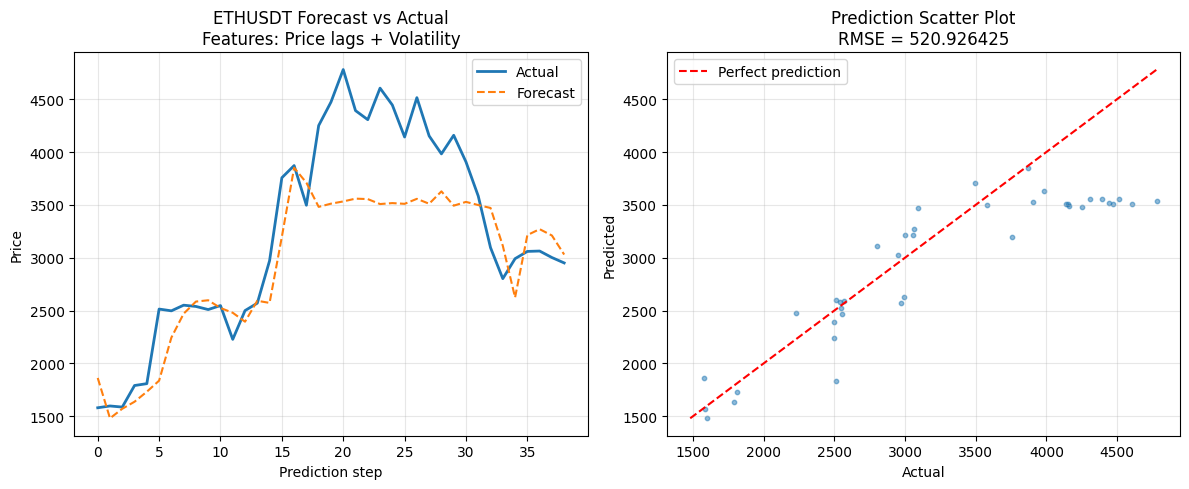

/tmp/ipykernel_4987/4090235654.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-10 09:42:19,251] A new study created in memory with name: no-name-99216809-2434-431d-a701-93dc27173e18



Training: BTCUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-10 09:42:19,657] Trial 0 finished with value: 24138.015498908626 and parameters: {'n_estimators': 252, 'max_depth': 4, 'learning_rate': 0.19725346332954613, 'subsample': 0.7209192423028188, 'colsample_bytree': 0.8206817098118764, 'gamma': 3.972767346416884, 'reg_alpha': 0.16349201570357352, 'reg_lambda': 1.3157386998821885}. Best is trial 0 with value: 24138.015498908626.
[I 2026-04-10 09:42:22,018] Trial 1 finished with value: 23567.029155072752 and parameters: {'n_estimators': 312, 'max_depth': 10, 'learning_rate': 0.01398322784566846, 'subsample': 0.806748859822803, 'colsample_bytree': 0.6973323873764941, 'gamma': 1.6836215821109963, 'reg_alpha': 0.7052120495339703, 'reg_lambda': 0.22279387139178763}. Best is trial 1 with value: 23567.029155072752.
[I 2026-04-10 09:42:22,364] Trial 2 finished with value: 21940.858436157876 and parameters: {'n_estimators': 418, 'max_depth': 3, 'learning_rate': 0.024193614927199306, 'subsample': 0.7711484456126175, 'colsample_bytree': 0.858

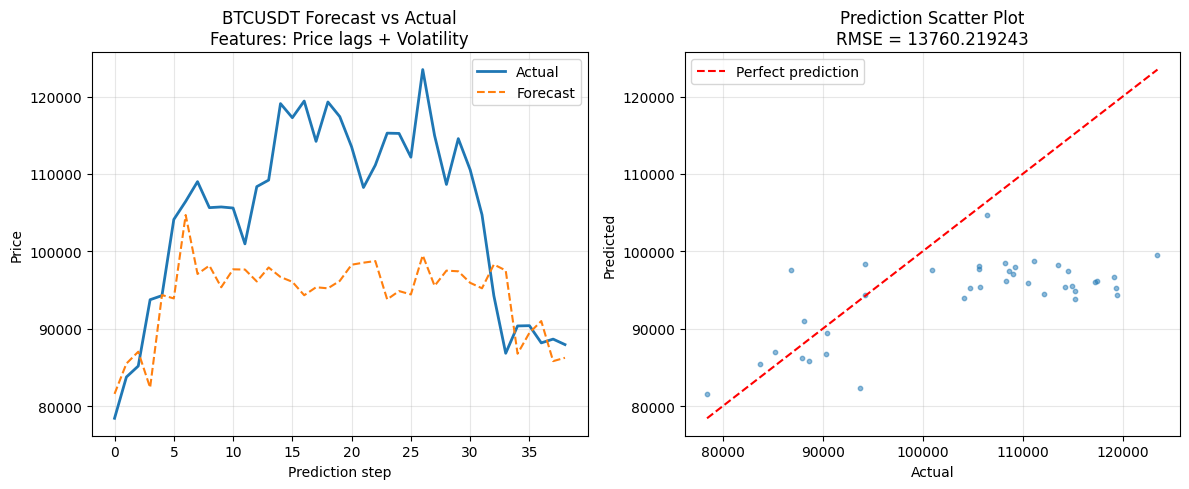

/tmp/ipykernel_4987/4090235654.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-10 09:42:49,689] A new study created in memory with name: no-name-07005739-ebf8-42c5-ac03-a4e982cd393e



Training: TRXUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-10 09:42:49,818] Trial 0 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 131, 'max_depth': 5, 'learning_rate': 0.04871273340372316, 'subsample': 0.9326892127138642, 'colsample_bytree': 0.7193013031899774, 'gamma': 1.8147305766783601, 'reg_alpha': 1.7622117421146637, 'reg_lambda': 2.8451890351221545}. Best is trial 0 with value: 0.12602966170678476.
[I 2026-04-10 09:42:49,948] Trial 1 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 216, 'max_depth': 3, 'learning_rate': 0.15204866308415332, 'subsample': 0.5396468464107074, 'colsample_bytree': 0.5570995016020446, 'gamma': 4.2373125974724966, 'reg_alpha': 4.239636656688271, 'reg_lambda': 2.3979532784143265}. Best is trial 0 with value: 0.12602966170678476.
[I 2026-04-10 09:42:50,115] Trial 2 finished with value: 0.12604623335393164 and parameters: {'n_estimators': 402, 'max_depth': 4, 'learning_rate': 0.12452395017356026, 'subsample': 0.7521704100526548, 'colsample_bytree': 0.6

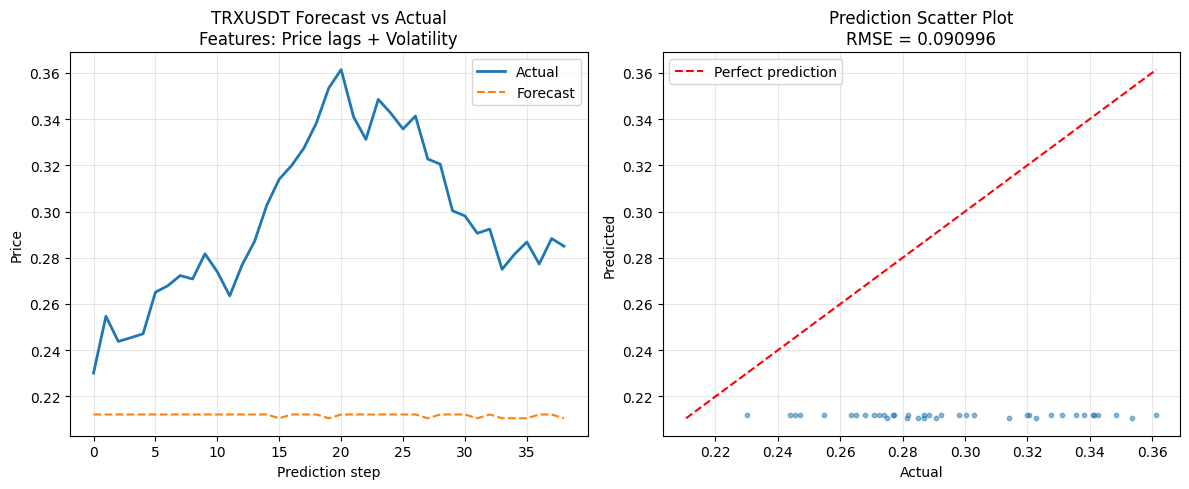

/tmp/ipykernel_4987/4090235654.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-10 09:42:56,784] A new study created in memory with name: no-name-0185d6ef-2fb0-408b-845e-d40f3f708b13



Training: XRPUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-10 09:42:57,155] Trial 0 finished with value: 1.387770108714973 and parameters: {'n_estimators': 359, 'max_depth': 8, 'learning_rate': 0.08460425220361335, 'subsample': 0.9391152143486037, 'colsample_bytree': 0.7341844195273178, 'gamma': 3.2657095014389843, 'reg_alpha': 0.012007420278142833, 'reg_lambda': 1.1275423736740882}. Best is trial 0 with value: 1.387770108714973.
[I 2026-04-10 09:42:57,286] Trial 1 finished with value: 1.3954073743931856 and parameters: {'n_estimators': 355, 'max_depth': 6, 'learning_rate': 0.056779785099912924, 'subsample': 0.898401843264271, 'colsample_bytree': 0.5344280565290385, 'gamma': 4.156201734489527, 'reg_alpha': 0.24870492149347945, 'reg_lambda': 1.6176631090019304}. Best is trial 0 with value: 1.387770108714973.
[I 2026-04-10 09:42:57,425] Trial 2 finished with value: 1.3921344285309287 and parameters: {'n_estimators': 311, 'max_depth': 3, 'learning_rate': 0.14255148156204123, 'subsample': 0.6809261126905934, 'colsample_bytree': 0.777146

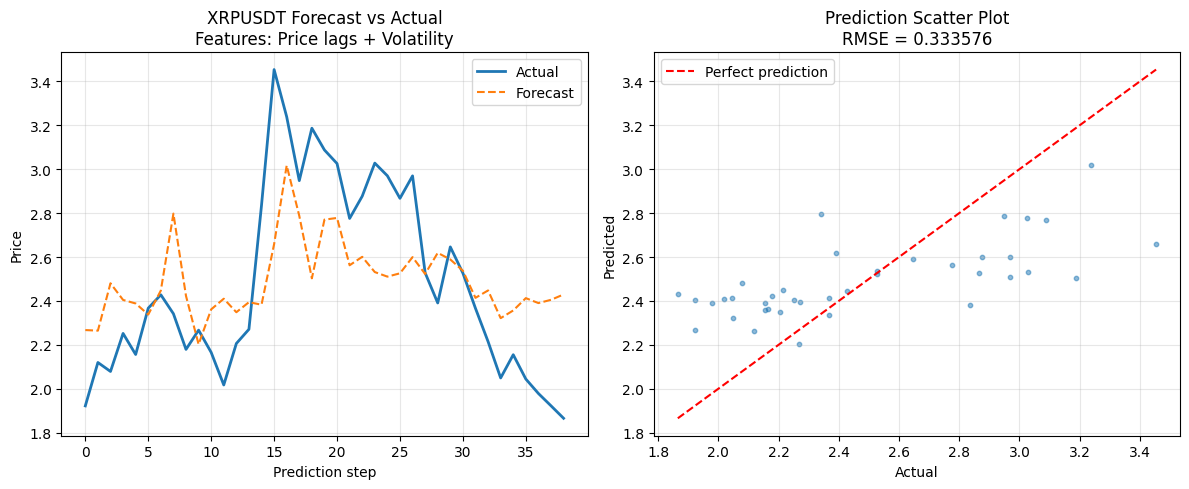

/tmp/ipykernel_4987/4090235654.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-10 09:43:02,186] A new study created in memory with name: no-name-ad49d649-2a72-4943-bb90-1a03a79adfc5



Training: ADAUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-10 09:43:02,428] Trial 0 finished with value: 0.33796239477166434 and parameters: {'n_estimators': 282, 'max_depth': 6, 'learning_rate': 0.12894389549298396, 'subsample': 0.5668527161151984, 'colsample_bytree': 0.6745209936336616, 'gamma': 2.4578288038998384, 'reg_alpha': 4.857729478609295, 'reg_lambda': 4.376437814648208}. Best is trial 0 with value: 0.33796239477166434.
[I 2026-04-10 09:43:02,532] Trial 1 finished with value: 0.3172879056752186 and parameters: {'n_estimators': 192, 'max_depth': 10, 'learning_rate': 0.07657542388501776, 'subsample': 0.6286410490044492, 'colsample_bytree': 0.6077523204265408, 'gamma': 1.6040487341413239, 'reg_alpha': 4.2498058072396505, 'reg_lambda': 1.0107050172874636}. Best is trial 1 with value: 0.3172879056752186.
[I 2026-04-10 09:43:02,632] Trial 2 finished with value: 0.3242444793661613 and parameters: {'n_estimators': 195, 'max_depth': 7, 'learning_rate': 0.18519997485455458, 'subsample': 0.7971123028912379, 'colsample_bytree': 0.6017

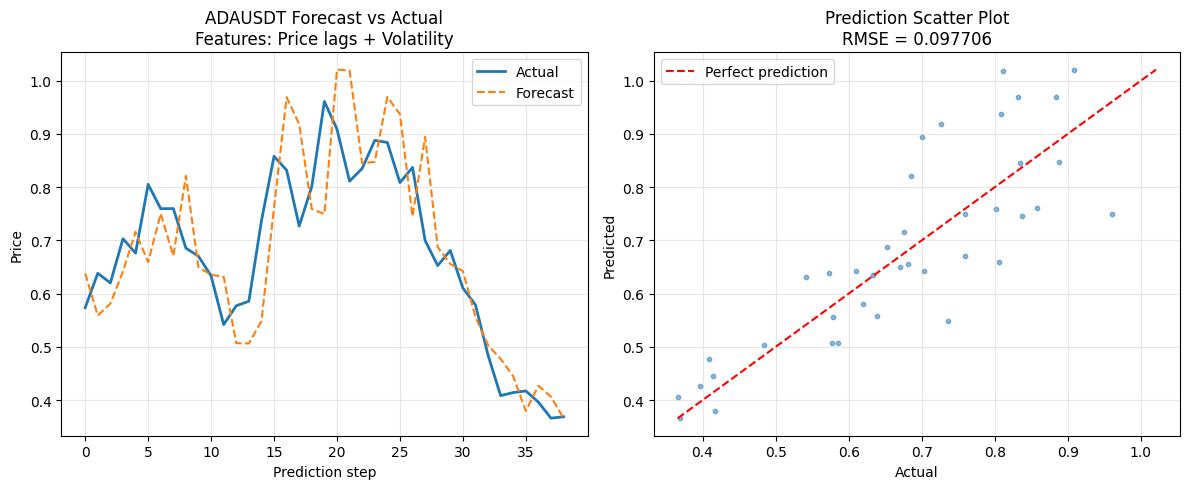

/tmp/ipykernel_4987/4090235654.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-10 09:43:06,847] A new study created in memory with name: no-name-371bb810-a1d6-4e1c-9df3-a8c297551fe1



Training: BNBUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-10 09:43:08,224] Trial 0 finished with value: 71.84646658871408 and parameters: {'n_estimators': 185, 'max_depth': 7, 'learning_rate': 0.10711177375663221, 'subsample': 0.8497903517437053, 'colsample_bytree': 0.7645268955245568, 'gamma': 1.719487650109492, 'reg_alpha': 0.7562328935639651, 'reg_lambda': 1.7894864890252093}. Best is trial 0 with value: 71.84646658871408.
[I 2026-04-10 09:43:10,921] Trial 1 finished with value: 73.36071422409262 and parameters: {'n_estimators': 340, 'max_depth': 9, 'learning_rate': 0.1508658375947424, 'subsample': 0.8994162966744756, 'colsample_bytree': 0.9185880397002841, 'gamma': 3.053888389951862, 'reg_alpha': 1.681898409267708, 'reg_lambda': 1.2824718084734632}. Best is trial 0 with value: 71.84646658871408.
[I 2026-04-10 09:43:12,067] Trial 2 finished with value: 71.49822165887505 and parameters: {'n_estimators': 339, 'max_depth': 7, 'learning_rate': 0.12119005172237098, 'subsample': 0.829007725995988, 'colsample_bytree': 0.559654981406919

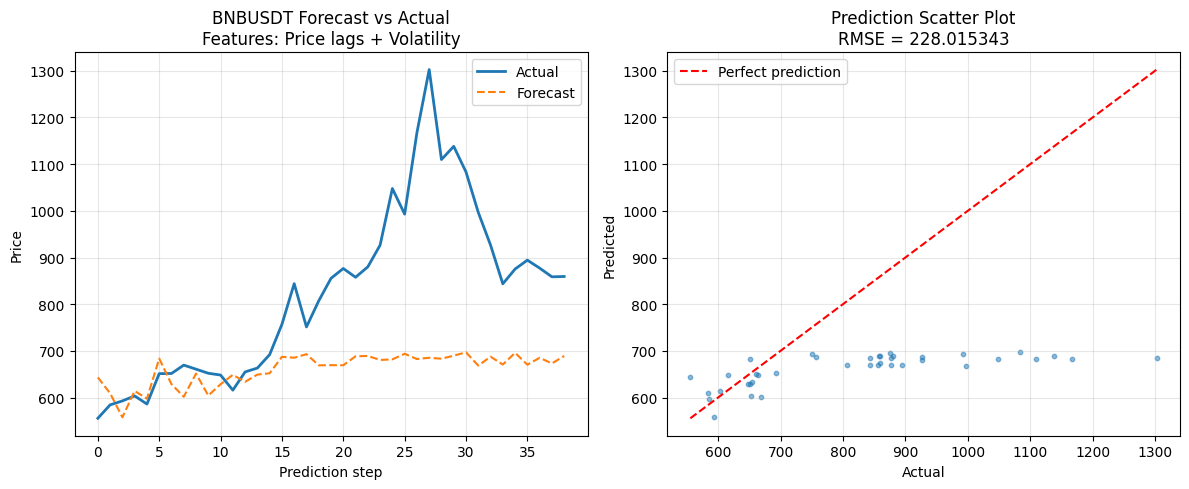

/tmp/ipykernel_4987/4090235654.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-10 09:43:27,899] A new study created in memory with name: no-name-726c35a6-0728-4188-8c51-42cc036d753a



Training: BCHUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-10 09:43:28,506] Trial 0 finished with value: 65.65763601379282 and parameters: {'n_estimators': 128, 'max_depth': 7, 'learning_rate': 0.09741182685984988, 'subsample': 0.9621553145834406, 'colsample_bytree': 0.585139555908494, 'gamma': 1.5247112772206994, 'reg_alpha': 0.43140266482992407, 'reg_lambda': 1.5964538435846565}. Best is trial 0 with value: 65.65763601379282.
[I 2026-04-10 09:43:29,638] Trial 1 finished with value: 61.77422924237807 and parameters: {'n_estimators': 374, 'max_depth': 7, 'learning_rate': 0.08074423074484711, 'subsample': 0.6413955290322888, 'colsample_bytree': 0.8786135255971175, 'gamma': 2.979388157880834, 'reg_alpha': 1.9227793834623308, 'reg_lambda': 4.525083096720563}. Best is trial 1 with value: 61.77422924237807.
[I 2026-04-10 09:43:30,277] Trial 2 finished with value: 61.23837583740929 and parameters: {'n_estimators': 496, 'max_depth': 4, 'learning_rate': 0.039288680857040244, 'subsample': 0.5301717321989947, 'colsample_bytree': 0.76625069917

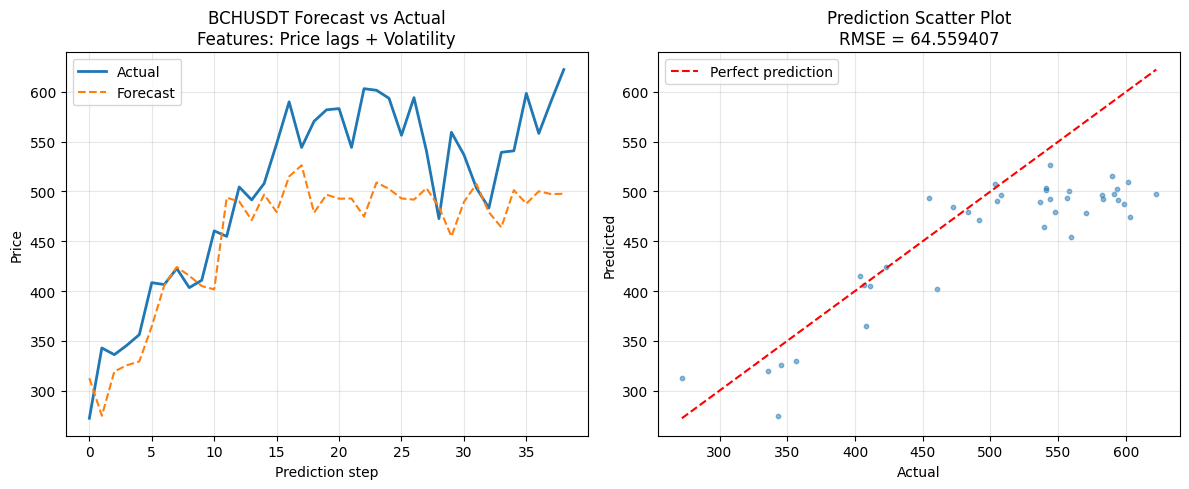


RMSE SUMMARY
                 RMSE  Mean_Actual_Price  NRMSE_Percent
TRXUSDT      0.090996           0.296315       0.307093
ADAUSDT      0.097706           0.671769       0.145446
XRPUSDT      0.333576           2.480085       0.134502
SOLUSDT     20.089979         167.505128       0.119937
BCHUSDT     64.559407         502.102564       0.128578
BNBUSDT    228.015343         820.774615       0.277805
ETHUSDT    520.926425        3219.931282       0.161782
BTCUSDT  13760.219243      104518.519744       0.131653

SUMMARY STATISTICS
Mean RMSE: 1824.291585
Median RMSE: 42.324693
Mean NRMSE (%): 0.1758%
Median NRMSE (%): 0.1400%
Best RMSE: 0.090996 (TRXUSDT)
Worst RMSE: 13760.219243 (BTCUSDT)


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import optuna

data_folder = "/content/drive/My Drive/klines csv/monthly klines csv/prices_cleaned"
HORIZON = 7
N_LAGS = 14
VOLATILITY_WINDOW = 7

results = {}
all_tables = []

def create_features(df):
    df = df.copy()

    # log return
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))

    # volatility
    df["volatility"] = df["log_return"].rolling(window=VOLATILITY_WINDOW).std()

    # lagged prices only
    for i in range(1, N_LAGS + 1):
        df[f"lag_{i}"] = df["close"].shift(i)

    return df

files = os.listdir(data_folder)

for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv", "")
    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)
    df.columns = ["index", "close", "time"]

    df["close"] = pd.to_numeric(df["close"], errors="coerce")
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df = df.sort_values("time")
    df = df[["close"]]

    # tiny coins
    tiny_price = df["close"].median() < 0.01

    if tiny_price:
        print("Tiny price detected → using log price")
        df["close"] = np.log(df["close"])

    # add features: price lags + volatility only
    df = create_features(df)

    # target = future closing price HORIZON steps ahead
    df["target"] = df["close"].shift(-HORIZON)

    # drop rows with NaN
    df = df.dropna().reset_index(drop=True)

    # exclude target, keep everything else
    X = df.drop(columns=["target"])
    y = df["target"]

    split1 = int(len(df) * 0.6)
    split2 = int(len(df) * 0.8)

    X_train = X.iloc[:split1]
    X_val   = X.iloc[split1:split2]
    X_test  = X.iloc[split2:]

    y_train = y.iloc[:split1]
    y_val   = y.iloc[split1:split2]
    y_test  = y.iloc[split2:]

    print(f"Features used ({len(X.columns)} total):")
    price_lags = [col for col in X.columns if col.startswith("lag_")]
    vol_features = [col for col in X.columns if "vol" in col.lower()]
    other_features = [col for col in X.columns if col not in price_lags and col not in vol_features]

    print(f"  - Price lags: {len(price_lags)} features")
    print(f"  - Volatility features: {len(vol_features)} features")
    print(f"  - Other features: {len(other_features)} features")
    print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}, Test samples: {len(X_test)}")

    # Bayesian Optimisation
    def objective(trial):

        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "gamma": trial.suggest_float("gamma", 0, 5),
            "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
            "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
            "objective": "reg:squarederror",
            "random_state": 42
        }

        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train, verbose=False)

        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        return rmse

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=30, show_progress_bar=True)

    best_params = study.best_params
    print("Best params:", best_params)

    model = xgb.XGBRegressor(
        **best_params,
        objective="reg:squarederror",
        random_state=42
    )

    X_train_full = pd.concat([X_train, X_val], axis=0)
    y_train_full = pd.concat([y_train, y_val], axis=0)

    model.fit(X_train_full, y_train_full, verbose=False)

    feature_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))

    preds = []
    actual = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]

        if tiny_price:
            preds.append(np.exp(pred))
            actual.append(np.exp(y_test.iloc[i]))
        else:
            preds.append(pred)
            actual.append(y_test.iloc[i])

    rmse = np.sqrt(mean_squared_error(actual, preds))
    mean_actual_price = np.mean(actual)
    nrmse_percent = (rmse / mean_actual_price)

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Percent": nrmse_percent
    }

    print(f"\n{coin} RMSE: {rmse:.6f}")

    table = pd.DataFrame({
        "coin": coin,
        "actual": actual,
        "forecast": preds
    })

    all_tables.append(table)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(actual, label="Actual", linewidth=2)
    plt.plot(preds, label="Forecast", linestyle="--")
    plt.title(f"{coin} Forecast vs Actual\nFeatures: Price lags + Volatility")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.scatter(actual, preds, alpha=0.5, s=10)
    min_val = min(min(actual), min(preds))
    max_val = max(max(actual), max(preds))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect prediction")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Prediction Scatter Plot\nRMSE = {rmse:.6f}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

final_table = pd.concat(all_tables, ignore_index=True)
final_table.to_csv("NEW!_xgboost_forecasts_BO_price_vol.csv", index=False)

rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("RMSE")

print("\n" + "="*60)
print("RMSE SUMMARY")
print("="*60)
print(rmse_table)
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Mean RMSE: {rmse_table['RMSE'].mean():.6f}")
print(f"Median RMSE: {rmse_table['RMSE'].median():.6f}")
print(f"Mean NRMSE (%): {rmse_table['NRMSE_Percent'].mean():.4f}%")
print(f"Median NRMSE (%): {rmse_table['NRMSE_Percent'].median():.4f}%")
print(f"Best RMSE: {rmse_table['RMSE'].min():.6f} ({rmse_table.index[rmse_table['RMSE'].argmin()]})")
print(f"Worst RMSE: {rmse_table['RMSE'].max():.6f} ({rmse_table.index[rmse_table['RMSE'].argmax()]})")

rmse_table.to_csv("NEW!xgboost_rmse_summary_BO_price_vol.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>